# Het bezoekvolume van de spoedeisende hulp voorspellen met exponentiële effening (PROC ESM)


## Managementsamenvatting

Een middelgroot ziekenhuissysteem heeft een jaarvooruitblik nodig van het maandelijkse bezoekvolume van de spoedeisende hulp (SEH) om de verpleegkundige bezetting en bedcapaciteit te plannen vóór de winterse respiratoire piek. Dit notebook bouwt een synthetische maandelijkse SEH-telling over vier jaar (48 maanden, jan 2021 - dec 2024) en past een multiplicatief Winters-seizoensmodel toe met **PROC ESM** om een prognose van 12 maanden met 95%-voorspellingsintervallen te produceren.

Het geschatte model vangt de reeks goed: de **RMSE binnen de steekproef is ongeveer 320 bezoeken** en de **MAPE is 4.16%**, dus de typische maandfout ligt onder 5% van het volume. De prognose projecteert de vertrouwde seizoensvorm naar 2025 - een piek in december-februari nabij **7,300-7,800 bezoeken/maand** en een dal in de nazomer nabij **5,800-5,900** - met voorspellingsbanden die breder worden naarmate de horizon zich uitstrekt. Die getallen, en de effeningsgewichten erachter, worden hieronder rechtstreeks afgelezen uit de outputdatasets van de procedure.


## Gegevensbronnen

| Dataset | Rijen | Granulariteit | Sleutelvariabelen | Beschrijving |
|---------|------|-------|---------------|-------------|
| `ed_census` | 48 | Eén rij per kalendermaand, jan 2021 - dec 2024 | `month` (maandelijkse SAS-datum), `ed_visits` (geheel maandelijks SEH-bezoekaantal) | Synthetisch maandelijks bezoekvolume van de spoedeisende hulp voor een middelgroot ziekenhuissysteem. Gegenereerd met een opwaartse groeitrend (~3% per jaar), een multiplicatieve seizoenscyclus die piekt in het winterse respiratoire seizoen (dec-feb) en daalt in de nazomer, plus log-normale ruis zodat de seizoensamplitude meeschaalt met het stijgende niveau. |


# Het bezoekvolume van de spoedeisende hulp voorspellen met PROC ESM

Capaciteitsplanners moeten weten hoeveel SEH-bezoeken ze elke maand kunnen verwachten, zodat ze verpleegkundigen kunnen inroosteren, flexbedden kunnen vrijhouden en respiratoire voorraden kunnen klaarzetten vóór de winterpiek. Het SEH-volume is een schoolvoorbeeld van een seizoensgebonden tijdreeks: het groeit langzaam jaar op jaar, piekt tijdens het respiratoire seizoen van december tot februari en ebt weg in de nazomer, en de omvang van de seizoensschommeling groeit mee met het basisvolume. Precies die multiplicatieve seizoensstructuur is wat de multiplicatieve Winters-methode in **PROC ESM** bedoeld is te vangen.

In dit notebook doen we het volgende:

1. Een realistische maandelijkse SEH-telling over vier jaar genereren met trend, multiplicatieve seizoensinvloed en ruis.
2. De reeks visualiseren om de multiplicatieve seizoensstructuur te bevestigen.
3. Een multiplicatief Winters-model schatten met PROC ESM en de effeningsgewichten en fit-statistieken uit de outputdatasets aflezen.
4. Een prognose van 12 maanden vooruit met 95%-voorspellingsintervallen produceren en de operationele implicaties interpreteren.


## Stap 1 - De synthetische maandelijkse SEH-telling genereren

We bouwen 48 maandelijkse observaties van januari 2021 tot en met december 2024. Het verwachte volume van elke maand is een basisniveau dat ongeveer 3% per jaar groeit, vermenigvuldigd met een seizoensindex (hoogst midden in de winter, laagst in de nazomer), en vervolgens verstoord met log-normale ruis zodat de willekeurige variatie meeschaalt met het niveau. `intnx` schuift de op de maand uitgelijnde datum één periode per rij op, en `streaminit` maakt de trekking reproduceerbaar.


In [1]:
GEGEVENS ed_census;
    CALL streaminit(20240531);
    /* Monthly seasonal index: peaks Dec-Feb (flu/RSV), troughs Aug-Sep */
    REEKS seas{12} _temporary_
        (1.18 1.14 1.05 0.97 0.93 0.90 0.92 0.86 0.88 0.97 1.06 1.14);
    OPMAAK month yymmn6.;
    DOE i = 1 TOT 48;
        month = intnx('month', '01JAN2021'd, i - 1);
        m = month(month);
        /* Baseline ~6000 visits/mo growing ~3% per year */
        level = 6000 * (1.03 ** ((i - 1) / 12));
        /* Multiplicative seasonality + level-scaled lognormal noise */
        noise = EXP(rand('normal', 0, 0.035));
        ed_visits = round(level * seas{m} * noise);
        UITVOER;
    EINDE;
    BEWAREN month ed_visits;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=ed_census(obs=14) noobs label;
    label month = 'Maand' ed_visits = 'SEH-bezoeken';
    TITEL 'Eerste 14 maanden synthetisch SEH-bezoekvolume';
UITVOEREN;


                                     Eerste 14 maanden synthetisch SEH-bezoekvolume                                     

 Maand  SEH-bezoeken
202101          7103
202102          6835
202103          6668
202104          5611
202105          5816
202106          5383
202107          5586
202108          5283
202109          5161
202110          6109
202111          6451
202112          6730
202201          6847
202202          7213

... 34 more observations (showing 14 of 48)




NOTE: DATA ed_census


NOTE: Wrote ed_census (48 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ed_census

NOTE: PROC PRINT completed: 14 observations printed, 2 variables


De eerste maanden bevestigen het ontwerp: het volume opent nabij 7,100 in de piek van januari 2021, daalt door lente en zomer naar het dal van augustus-september, en klimt dan weer op naar de volgende winter. Tegen januari 2022 is de piek opgeklommen tot ongeveer 6,800-7,200, wat de ~3% jaarlijkse groei weerspiegelt die op de seizoenscyclus is gelegd.


## Stap 2 - De reeks visualiseren

Voordat we modelleren, plotten we de ruwe reeks om de verwachte structuur te bevestigen: een lichte opwaartse trend met een terugkerende jaarlijkse piek elke winter waarvan de amplitude in de loop van de tijd breder wordt. Een breder wordende seizoensschommeling is het kenmerk van een *multiplicatief* seizoensproces en vertelt ons welk ESM-model we moeten kiezen.


                                     Eerste 14 maanden synthetisch SEH-bezoekvolume                                     




NOTE: PROC SGPLOT data=ed_census

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


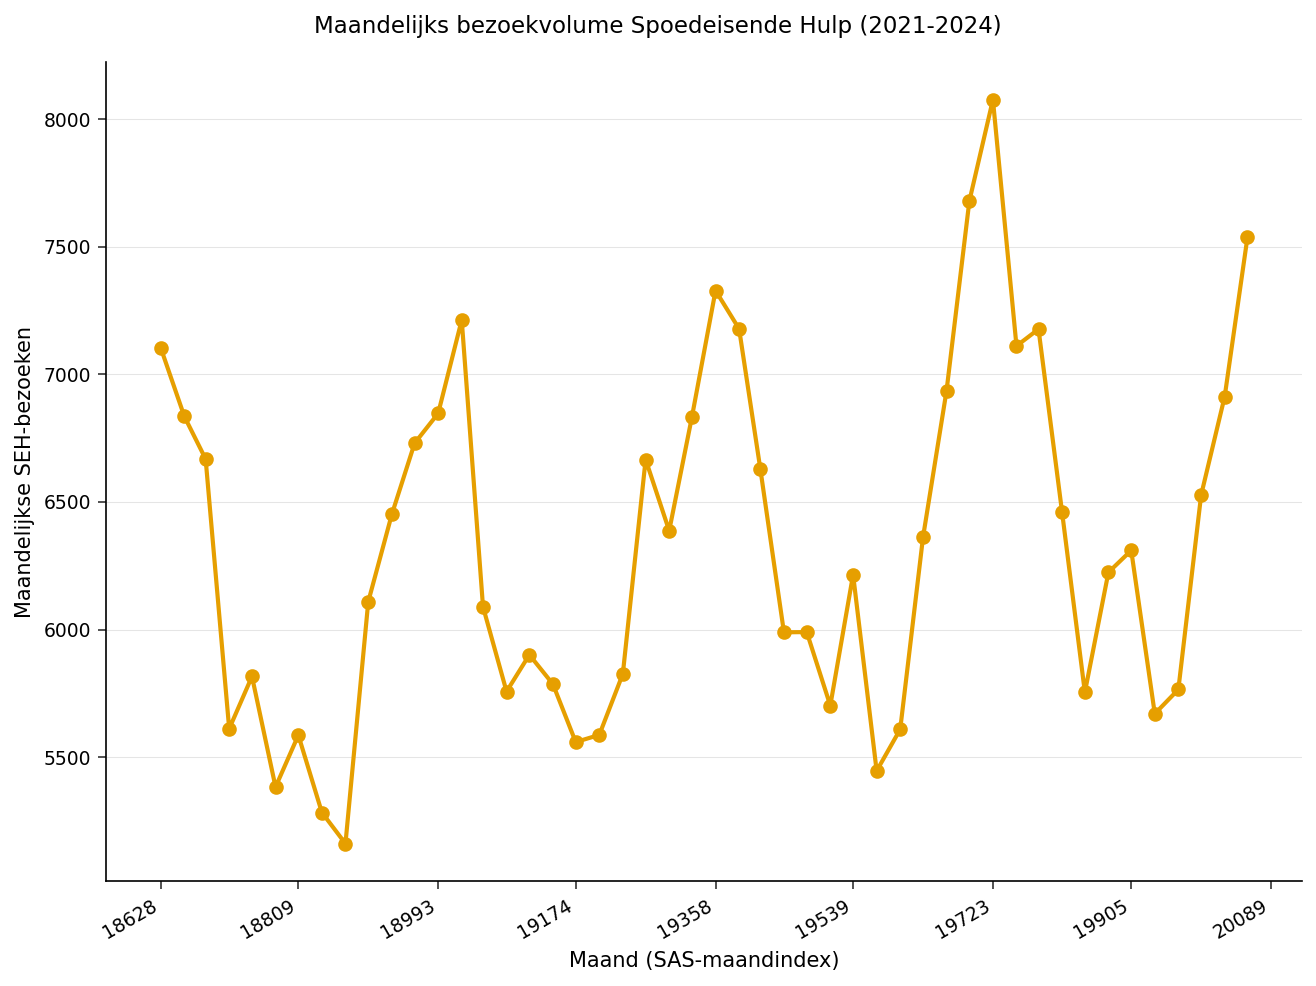

In [2]:
PROCEDURE SGPLOT GEGEVENS=ed_census;
    SERIES x=month y=ed_visits / MARKERS
        MARKERATTRS=(SYMBOL=circlefilled)
        LINEATTRS=(thickness=2);
    XAXIS label='Maand (SAS-maandindex)';
    YAXIS label='Maandelijkse SEH-bezoeken' grid;
    TITEL 'Maandelijks bezoekvolume Spoedeisende Hulp (2021-2024)';
UITVOEREN;


De plot toont vier zuivere jaarcycli. Elke winterpiek ligt iets hoger dan de vorige, oplopend van ruwweg 7,100 in 2021 tot ongeveer 8,100 bij de piek van 2024, terwijl de zomerdalen bescheidener stijgen - de seizoensschommeling groeit mee met het niveau. Die breder wordende amplitude is het kenmerk van multiplicatieve seizoensinvloed en rechtvaardigt `MODEL=WINTERS` (Winters multiplicatief) in de volgende stap.


## Stap 3 - Het multiplicatieve Winters-model schatten

We passen multiplicatieve Winters-seizoenseffening toe op de volledige geschiedenis van 48 maanden. De `ID`-instructie declareert `month` als de tijdsindex met een `MONTH`-interval, en de `FORECAST`-instructie vraagt `MODEL=WINTERS` met `LEAD=12` aan om een jaar vooruit te projecteren. We leggen drie outputdatasets vast:

- `OUT=` - de historische reeks met de prognose eraan toegevoegd (één `ed_visits`-kolom), met de tijds-ID uitgebreid over de prognosehorizon - ideaal om te plotten.
- `OUTFOR=` - de prognosecomponenten per periode: puntprognose (`PREDICT`) en de onder-/bovengrenzen van de voorspelling.
- `OUTSUM=` - de fit-statistieken van het model (RMSE, MAE, MAPE, AIC) en de effeningsgewichten, in één samenvattingsrij.

`ALPHA=0.05` levert 95%-voorspellingsgrenzen op, passend bij risicomarges voor capaciteitsplanning. `PRINT=(STATISTICS)` echoot de fit-statistieken en effeningsgewichten naar de listing.


In [3]:
PROCEDURE esm GEGEVENS=ed_census
        LEAD=12
        out=ed_with_forecast
        outfor=esm_forecast
        outsum=esm_summary
        AFDRUKKEN=(statistics);
    id month interval=month;
    forecast ed_visits / MODEL=winters ALPHA=0.05;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=esm_summary noobs label;
    label rmse='RMSE' mae='MAE' mape='MAPE'
          ALPHA='Niveau (alpha)' beta='Trend (beta)' gamma='Seizoen (gamma)';
    VARIABELE rmse mae mape ALPHA beta gamma;
    TITEL 'Winters-fitstatistieken en gladstrijkgewichten';
UITVOEREN;


                                     Eerste 14 maanden synthetisch SEH-bezoekvolume                                     


Exponential Smoothing Forecast for ed_visits
Method: WINTERS
Number of Observations: 48
Forecast Periods: 12

Fit Statistics:
  RMSE     = 320.4349
  MAE      = 264.4440
  MAPE     = 4.1597
  MSE      = 102678.4971
  AIC      = 421.4169

Smoothing Weights:
  ALPHA      = 0.3000
  BETA       = 0.1000
  GAMMA      = 0.1000

Forecasts:
  Period     Predict        
  1          7822.1805      
  2          7538.7511      
  3          7291.7885      
  4          6262.7158      
  5          6396.7222      
  6          6039.1562      
  7          6235.5688      
  8          5867.3108      
  9          5801.6677      
  10         6803.9608      
  11         7172.6105      
  12         7566.8263      



                                     Winters-fitstatistieken en gladstrijkgewichten                                     

          RMSE            MAE         MA


NOTE: PROC ESM data=ed_census

NOTE: Using Python for ESM estimation
NOTE: Output dataset ED_WITH_FORECAST created with 60 observations.
NOTE: Output dataset ESM_FORECAST created with 60 observations.
NOTE: PROC PRINT data=esm_summary

NOTE: PROC PRINT completed: 1 observations printed, 6 variables


De `OUTSUM=`-rij en de geprinte statistieken komen overeen: de multiplicatieve Winters-fit behaalt binnen de steekproef een **RMSE van 320.4 bezoeken**, een **MAE van 264.4** en een **MAPE van 4.16%** - een typische maandfout ruim onder 5% van het volume, wat comfortabel nauwkeurig is voor bezettingsplanning. De effeningsgewichten zijn **alpha = 0.30** (niveau), **beta = 0.10** (trend) en **gamma = 0.10** (seizoen). Het gematigde niveaugewicht laat het basisniveau opwaarts driften met de groei van de patiëntenpopulatie, terwijl de kleine trend- en seizoensgewichten weerspiegelen dat het groeitempo en de vorm van de winterpiek jaar op jaar stabiel zijn en niet van maand tot maand overdreven moeten worden gevolgd.

> Let op: dit zijn fit-statistieken *binnen de steekproef*, berekend over de schattingssteekproef, niet een out-of-sample holdout. Ze kwantificeren hoe nauw het model de geschiedenis volgt waarop het is geschat.


## Stap 4 - De prognose van 12 maanden samenstellen en tabelleren

De `OUTFOR=`-dataset bevat de puntprognose en voorspellingsgrenzen voor elke periode, terwijl de `OUT=`-dataset de tijds-ID netjes uitgebreid over de prognosehorizon draagt. We lijnen de twee uit op observatievolgorde om de prognosedata aan de voorspellingsgrenzen te koppelen, en houden vervolgens alleen de 12 prognosemaanden over. Dit zijn de getallen waarop een bezettingscommissie zou handelen.


In [4]:
/* OUT= carries the forecast-horizon dates; OUTFOR= carries the
   prediction limits. Align them by observation order to put dates on
   the limits, then keep only the 12 forecast months.            */
GEGEVENS out_idx;
    INSTELLEN ed_with_forecast;
    row = _n_;
    HERNOEMEN month = fdate ed_visits = series_value;
UITVOEREN;

GEGEVENS for_idx;
    INSTELLEN esm_forecast;
    row = _n_;
    HERNOEMEN ed_visits = observed;
    BEWAREN row observed predict LOWER UPPER;
UITVOEREN;

GEGEVENS forecast_path;
    SAMENVOEGEN out_idx for_idx;
    VOLGENS row;
    OPMAAK fdate yymmn6. series_value observed predict LOWER UPPER comma8.0;
UITVOEREN;

GEGEVENS forecast_horizon;
    INSTELLEN forecast_path;
    WAAR observed = .;   /* forecast months only (no observed value) */
    BEWAREN fdate predict LOWER UPPER;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=forecast_horizon noobs label;
    label fdate   = 'Maand'
          predict = 'Prognose bezoeken'
          LOWER   = '95% ondergrens'
          UPPER   = '95% bovengrens';
    TITEL '12-maands SEH-bezoekprognose met 95%-voorspellingsgrenzen';
UITVOEREN;


                               12-maands SEH-bezoekprognose met 95%-voorspellingsgrenzen                                

 Maand  Prognose bezoeken  95% ondergrens  95% bovengrens
202501              7,822           7,194           8,450
202502              7,539           6,651           8,427
202503              7,292           6,204           8,380
202504              6,263           5,007           7,519
202505              6,397           4,992           7,801
202506              6,039           4,501           7,578
202507              6,236           4,574           7,897
202508              5,867           4,091           7,644
202509              5,802           3,918           7,686
202510              6,804           4,818           8,790
202511              7,173           5,090           9,256
202512              7,567           5,391           9,742




NOTE: DATA out_idx


NOTE: Read 60 rows from ed_with_forecast.
NOTE: Wrote out_idx (60 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA for_idx


NOTE: Read 60 rows from esm_forecast.
NOTE: Wrote for_idx (60 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_path

NOTE: Stream 1 processed 60 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 60 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote forecast_path (60 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_horizon


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_horizon (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=forecast_horizon

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


De prognose draagt de seizoenssignatuur door naar 2025. Het model projecteert de piek van januari 2025 op ongeveer **7,822 bezoeken** (95%-interval 7,194-8,450), zwakt af in de lente, bereikt het laagste punt in het nazomerdal nabij **5,802** in september (interval 3,918-7,686), en bouwt vervolgens weer op naar een decemberpiek van ruwweg **7,567** (interval 5,391-9,742). De voorspellingsband wordt gestaag breder met de horizon - het interval van volgende maand beslaat ongeveer +/-630 bezoeken, terwijl dat van komende december meer dan +/-2,000 beslaat - een directe herinnering dat plannen op korte termijn veel steviger zijn dan die aan het jaareinde.


## Stap 5 - Geschiedenis plus prognose plotten

Ten slotte leggen we de prognose over de waargenomen geschiedenis heen zodat planners de geprojecteerde winterpiek en de breder wordende onzekerheidsband kunnen zien naarmate de horizon zich uitstrekt. We splitsen de uitgelijnde `forecast_path`-reeks in de **waargenomen** geschiedenis (doorgetrokken) en de **prognose van 12 maanden** (gestreept) zodat de overgang duidelijk is, en tekenen de 95%-voorspellingsband eronder. De x-as is de maandelijkse SAS-datumindex, die van links naar rechts loopt van jan 2021 tot en met dec 2025.


                               12-maands SEH-bezoekprognose met 95%-voorspellingsgrenzen                                




NOTE: DATA forecast_plot


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_plot (60 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=forecast_plot

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


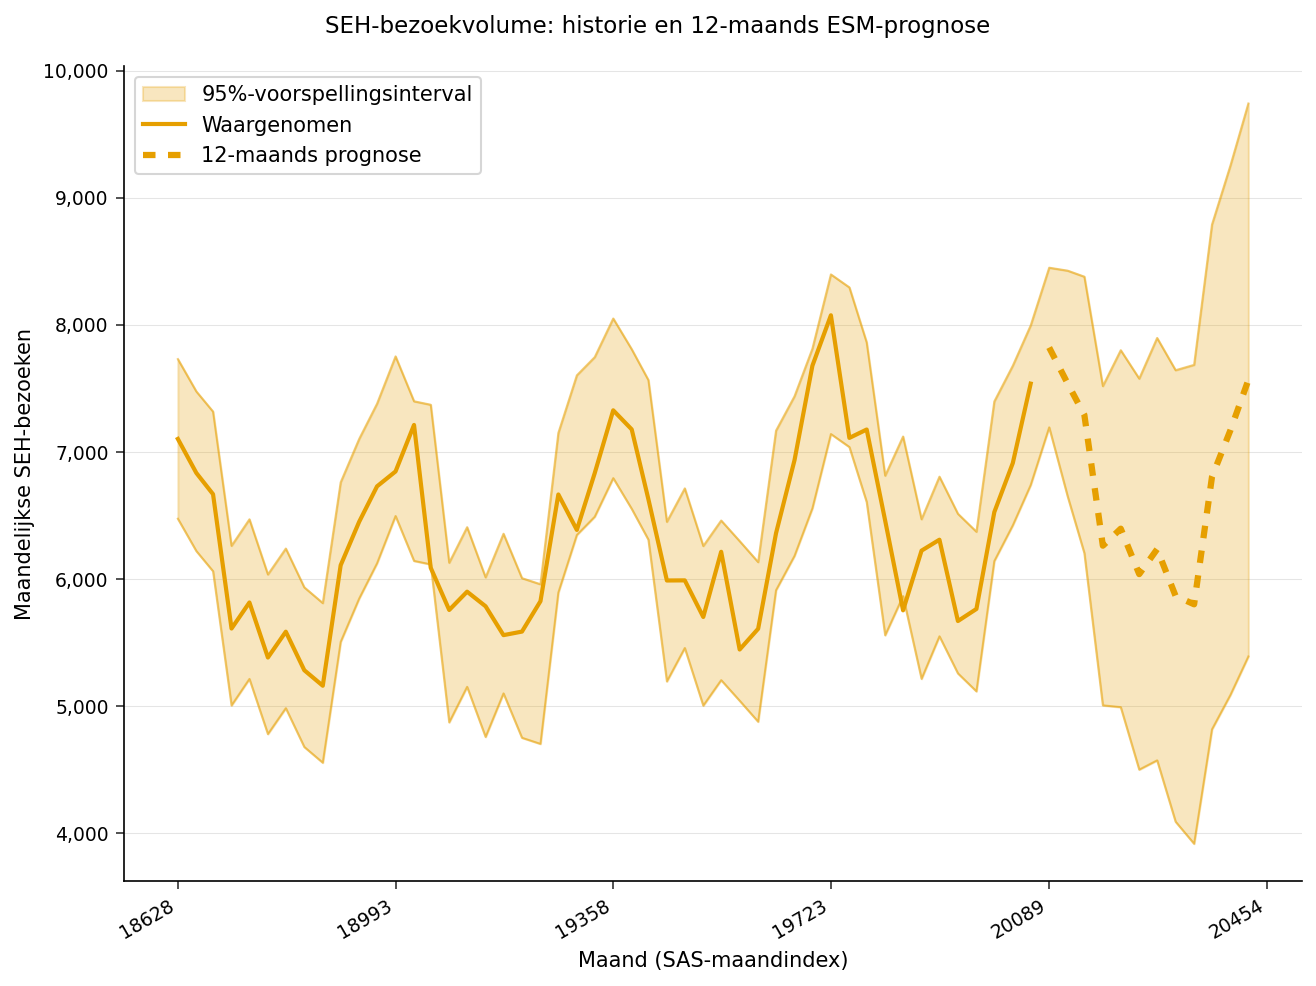

In [5]:
/* Split the projected series into the observed history and the
   12-month forecast so they render with distinct styling, and overlay
   the 95% prediction band from the aligned forecast_path dataset.   */
GEGEVENS forecast_plot;
    INSTELLEN forecast_path;
    ALS observed = . DAN fc_only = predict;   /* future months only */
    ANDERS fc_only = .;
UITVOEREN;

PROCEDURE SGPLOT GEGEVENS=forecast_plot;
    BAND x=fdate LOWER=LOWER UPPER=UPPER /
        legendlabel='95%-voorspellingsinterval' TRANSPARENCY=0.5;
    SERIES x=fdate y=observed / LINEATTRS=(thickness=2)
        legendlabel='Waargenomen';
    SERIES x=fdate y=fc_only / LINEATTRS=(thickness=3 pattern=shortdash)
        legendlabel='12-maands prognose';
    XAXIS label='Maand (SAS-maandindex)';
    YAXIS label='Maandelijkse SEH-bezoeken' grid;
    TITEL 'SEH-bezoekvolume: historie en 12-maands ESM-prognose';
UITVOEREN;


## De resultaten interpreteren

Het multiplicatieve Winters-model ontleedt het SEH-volume in een langzaam stijgend **niveau**, een vrijwel vlakke **trend** en een stabiel **seizoenspatroon**. De uit `OUTSUM=` afgelezen effeningsgewichten vertellen het verhaal: een gematigd niveaugewicht (alpha = 0.30) laat het basisniveau opwaarts driften met de groei van de patiëntenpopulatie, terwijl kleine trend- en seizoensgewichten (beta = gamma = 0.10) weerspiegelen dat het groeitempo en de vorm van de winterpiek jaar op jaar zeer stabiel zijn en niet van maand tot maand overdreven moeten worden gevolgd.

De **fit-statistieken** bevestigen dat het model de geschiedenis goed volgt: een RMSE van ongeveer 320 bezoeken en een MAPE van 4.16% betekenen dat de typische maandfout onder 5% van het volume ligt. Operationeel kwantificeren de **prognosetabel en de bandplot** de piek van december tot februari waarnaar de SEH moet bemensen - ruwweg 7,300-7,800 bezoeken in de wintermaanden - en de 95%-voorspellingsgrenzen definiëren een verstandige capaciteitsrange: plan de kernbezetting op de puntprognose en regel flexdekking en piekbedden vooraf richting de bovengrens. Het interval wordt breder met de horizon, dus het plan voor volgende maand is veel steviger dan dat voor komende december en moet worden ververst zodra nieuwe werkelijke cijfers binnenkomen.

**Uitbreidingen:** vergelijk `MODEL=ADDWINTERS` (additieve seizoensinvloed) met de multiplicatieve fit om de multiplicatieve keuze te bevestigen; pas `TRANSFORM=LOG` toe om positiviteit af te dwingen en de variantie te stabiliseren; of voeg een `BY`-instructie toe om meerdere ziekenhuislocaties in één PROC ESM-aanroep te voorspellen.
